<a href="https://colab.research.google.com/github/palayushi293/i2v_round2/blob/main/vehicledetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.1 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import zipfile
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [4]:
zip_path = "dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted!")

Dataset extracted!


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [6]:
train_dir = "/content/dataset/vehicle_dataset/train"
val_dir = "/content/dataset/vehicle_dataset/val"

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

classes = os.listdir(train_dir)

data = []

for c in classes:
    path = os.path.join(train_dir, c)
    count = len(os.listdir(path))
    data.append([c, count])

df = pd.DataFrame(data, columns=["Class","Count"])
print(df)

            Class  Count
0   auto-rickshaw    448
1         bicycle    263
2      motorcycle    245
3             car    117
4         tractor     81
5             bus    213
6      e-rickshaw     97
7           truck    481
8        mini-bus     12
9      mini-truck    387
10       rickshaw     24
11            van    351


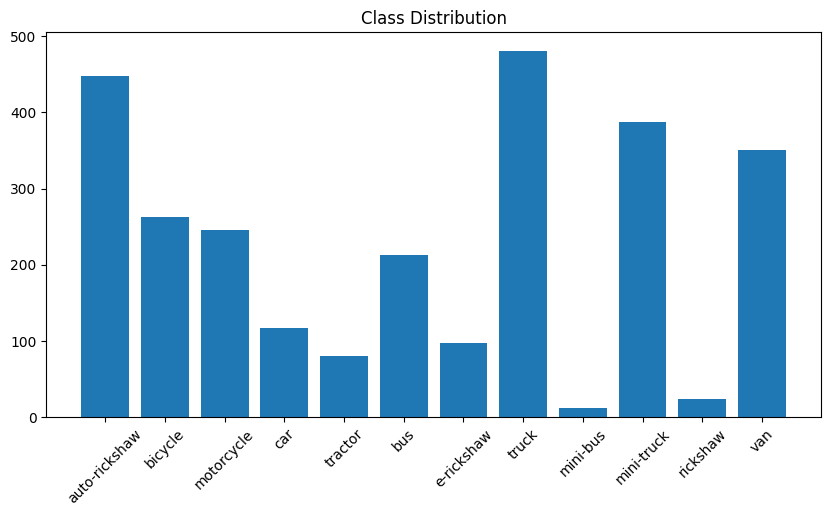

In [10]:
plt.figure(figsize=(10,5))
plt.bar(df["Class"], df["Count"])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

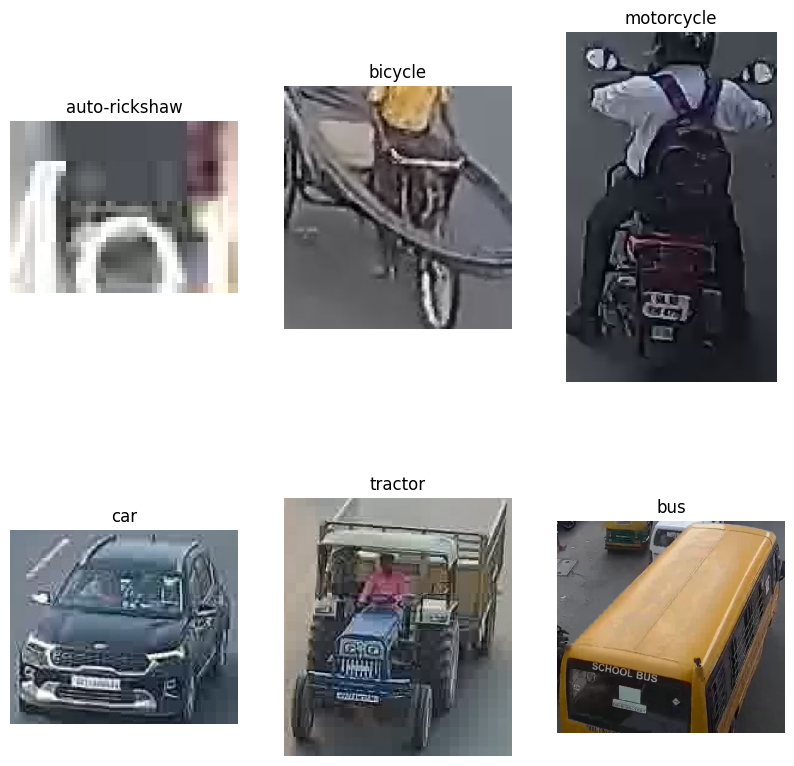

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(10,10))

for i, c in enumerate(classes[:6]):
    img_path = os.path.join(train_dir, c, random.choice(os.listdir(os.path.join(train_dir,c))))

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")

plt.show()

In [12]:
from PIL import Image

sizes = []

for c in classes:
    path = os.path.join(train_dir,c)

    for img_name in os.listdir(path)[:50]:
        img = Image.open(os.path.join(path,img_name))
        sizes.append(img.size)

print("Sample image sizes:", sizes[:10])

Sample image sizes: [(138, 193), (83, 99), (80, 97), (48, 64), (170, 172), (56, 80), (97, 140), (62, 80), (42, 282), (118, 149)]


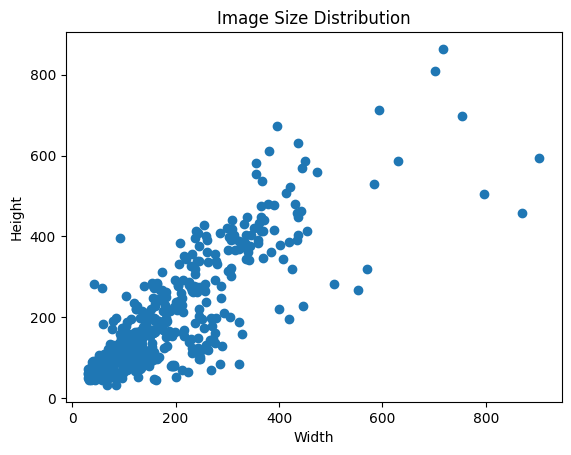

In [13]:
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.scatter(widths, heights)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")
plt.show()

In [14]:
from PIL import Image

bad_images = []

for c in classes:
    path = os.path.join(train_dir,c)

    for img in os.listdir(path):
        try:
            Image.open(os.path.join(path,img))
        except:
            bad_images.append(img)

print("Corrupt Images:", len(bad_images))

Corrupt Images: 0


In [15]:
print("Max samples:", df["Count"].max())
print("Min samples:", df["Count"].min())

Max samples: 481
Min samples: 12


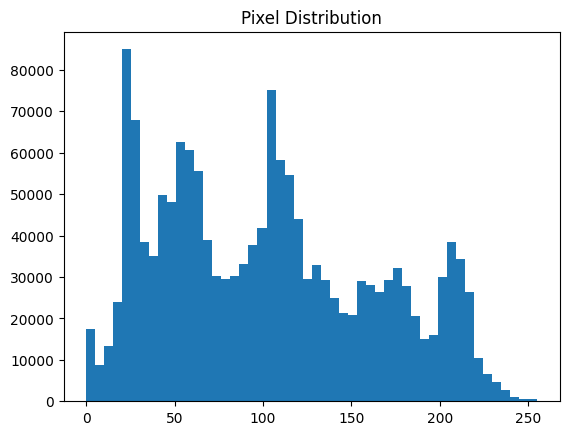

In [16]:
import numpy as np

img = Image.open(img_path)
img = np.array(img)

plt.hist(img.ravel(), bins=50)
plt.title("Pixel Distribution")
plt.show()

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

In [24]:
!ls /content/dataset

vehicle_dataset


In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2719 images belonging to 12 classes.
Found 765 images belonging to 12 classes.


In [35]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

In [36]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [37]:
for layer in base_model.layers:
    layer.trainable = False

In [38]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

output = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

In [39]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 76s 694ms/step - accuracy: 0.3867 - loss: 1.8030 - val_accuracy: 0.6275 - val_loss: 1.0913
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 33s 385ms/step - accuracy: 0.6931 - loss: 0.9514 - val_accuracy: 0.7242 - val_loss: 0.8404
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 33s 391ms/step - accuracy: 0.7472 - loss: 0.7687 - val_accuracy: 0.7046 - val_loss: 0.8505
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 32s 382ms/step - accuracy: 0.7952 - loss: 0.6031 - val_accuracy: 0.7451 - val_loss: 0.7953
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 34s 398ms/step - accuracy: 0.8268 - loss: 0.5298 - val_accuracy: 0.7634 - val_loss: 0.7764
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 33s 391ms/step - accuracy: 0.8578 - loss: 0.4379 - val_accuracy: 0.7830 - val_loss: 0.6946
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 32s 375ms/step - accuracy: 0.8509 - loss: 0.4255 - val_accuracy: 0.7503 - val_loss: 0.7402
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 33s 391ms/step - accuracy: 0.8634 - loss: 0.4149 - val_accu

In [41]:
val_loss, val_acc = model.evaluate(val_generator)

print("Validation Accuracy:", val_acc)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7736 - loss: 0.7095
Validation Accuracy: 0.7542483806610107


In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix

pred = model.predict(val_generator)

y_pred = np.argmax(pred, axis=1)
y_true = val_generator.classes

print(confusion_matrix(y_true, y_pred))

24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 272ms/step
[[109   1   3   1   2   0   8   6   0   1   5   1]
 [  1  56   0   0   1   0   0  11   0   0   0   0]
 [  2   0  56   1   1   0   6   0   0   0   4   1]
 [  3   1   4  12   0   0   2   4   0   1   2   6]
 [  2   0   0   0   4   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   1   0   0   0   0   0]
 [  6   0   3   2   0   0  88   0   0   0   1   2]
 [  1   2   0   0   0   0   0  65   1   0   0   0]
 [  0   0   0   0   1   0   0   0  11   0   0   0]
 [  1   0   0   0   0   0   0   0   0   2   0   0]
 [ 17   0  20   1   1   0  24   2   0   1  88   3]
 [  5   0   2   1   0   0   9   0   0   0   0  86]]


In [43]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=val_generator.class_indices.keys()
))

               precision    recall  f1-score   support

auto-rickshaw       0.74      0.80      0.77       137
      bicycle       0.93      0.81      0.87        69
          bus       0.64      0.79      0.70        71
          car       0.67      0.34      0.45        35
   e-rickshaw       0.40      0.67      0.50         6
     mini-bus       0.00      0.00      0.00         1
   mini-truck       0.64      0.86      0.73       102
   motorcycle       0.74      0.94      0.83        69
     rickshaw       0.92      0.92      0.92        12
      tractor       0.40      0.67      0.50         3
        truck       0.88      0.56      0.68       157
          van       0.87      0.83      0.85       103

     accuracy                           0.75       765
    macro avg       0.65      0.68      0.65       765
 weighted avg       0.77      0.75      0.75       765



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
